**Step 1: Import Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

**Step 2: Load Dataset**

In [4]:
df=pd.read_csv("Netflix_data_Analysis/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Step 3: Explore Dataset**

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [7]:
print("Rows and Columns:",df.shape)
df.columns

Rows and Columns: (8807, 12)


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

**Step 4: Data Cleaning and Missing Values**

In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
(df.isnull().sum()/len(df))*100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [13]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [18]:
df.describe(include='object')

C:\Users\yasha\AppData\Local\Temp\ipykernel_10292\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


**Step 5: Movies vs TV Shows**

In [19]:
type_count = df['type'].value_counts()

print(type_count)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


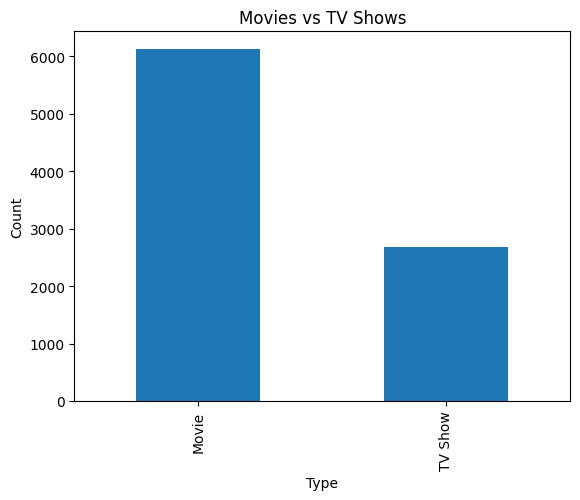

In [20]:
type_count.plot(kind='bar')

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

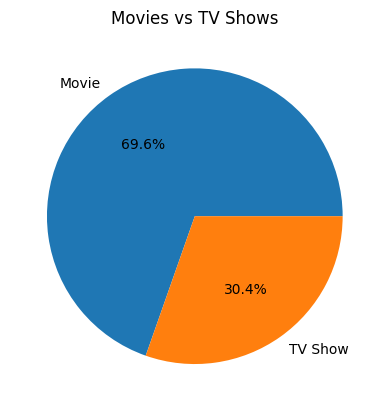

In [21]:
type_count.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Movies vs TV Shows")

plt.ylabel("")

plt.show()

**Step 6: Genre Analysis**

In [22]:
genre = df['listed_in'].str.split(', ').explode()

genre_count = genre.value_counts().head(10)

print(genre_count)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


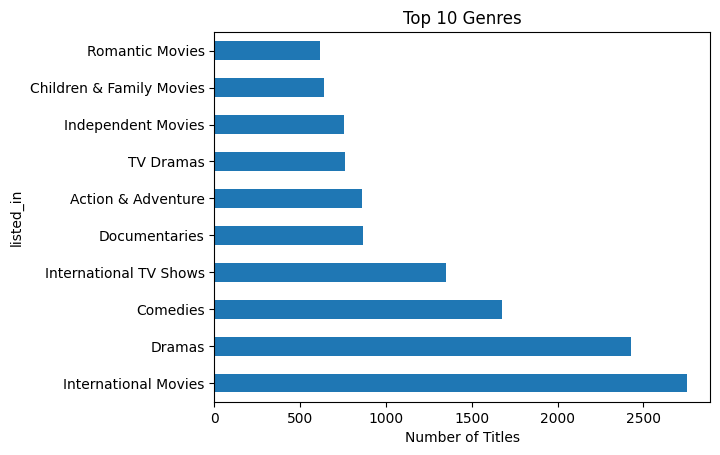

In [23]:
genre_count.plot(kind='barh')

plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")

plt.show()

**Step 7: Country Analysis**

In [24]:
country = df['country'].str.split(', ').explode()

country_count = country.value_counts().head(10)

print(country_count)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


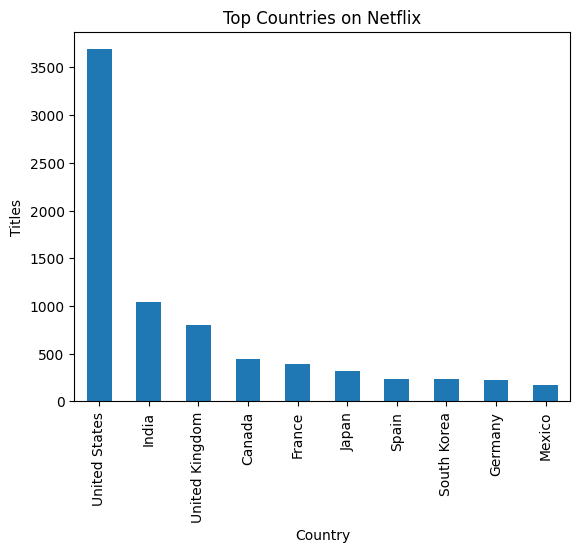

In [26]:
country_count.plot(kind='bar')

plt.title("Top Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Titles")

plt.xticks(rotation=90)

plt.show()

**Step 8: Ratings Analysis**

In [27]:
rating_count = df['rating'].value_counts()

print(rating_count)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


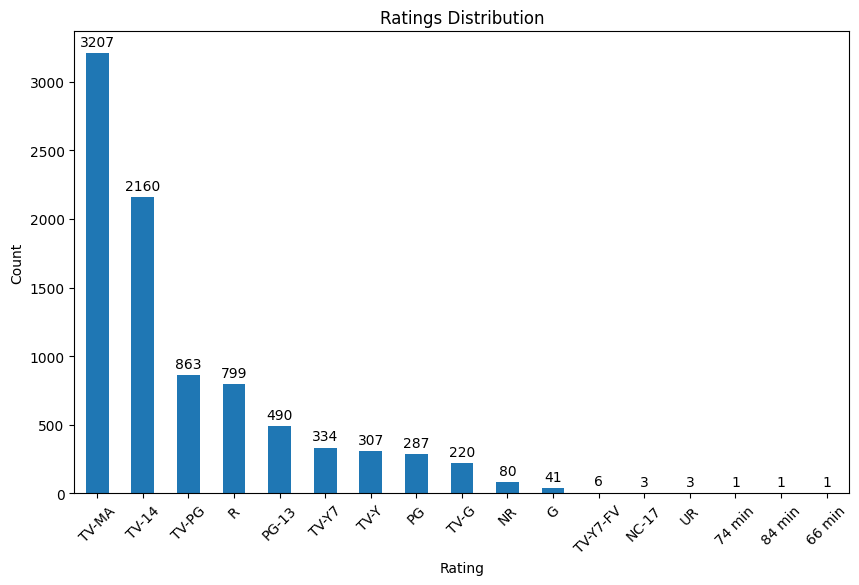

In [36]:
ax = rating_count.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

ax.bar_label(ax.containers[0], fmt='%d', padding=3)

plt.xticks(rotation=45)

plt.show()

**Step 9: Release Trend**

In [37]:
release = df['release_year'].value_counts().sort_index()

print(release)

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


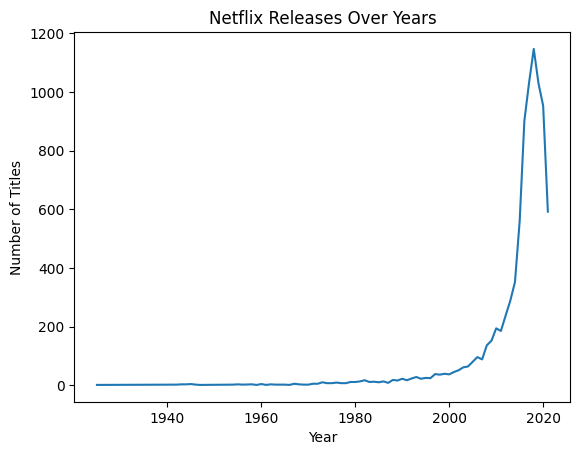

In [38]:
release.plot()

plt.title("Netflix Releases Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

**Step 10: Content Added Trend**

In [41]:
df['date_added'] = df['date_added'].str.strip()

df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

In [43]:
df['date_added'].isna().sum()

np.int64(10)

In [44]:
df['year_added'] = df['date_added'].dt.year

In [45]:
added = df['year_added'].dropna().value_counts().sort_index()

print(added)

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


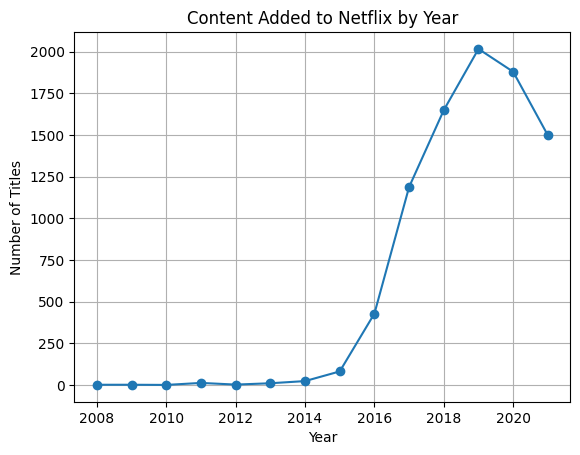

In [46]:
added.plot(kind='line', marker='o')

plt.title("Content Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)

plt.show()

**Step 11: Movie Duration Analysis**

In [54]:
movies = df[df['type'] == 'Movie'].copy()

movies['minutes'] = movies['duration'].str.replace(' min', '', regex=False)

movies['minutes'] = pd.to_numeric(movies['minutes'], errors='coerce')

In [55]:
movies['minutes'].isna().sum()

np.int64(3)

In [56]:
print("Average Duration:", movies['minutes'].mean())

Average Duration: 99.57718668407311


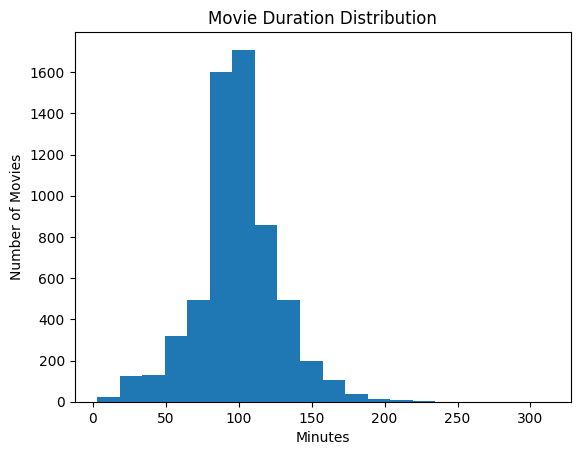

In [57]:
movies['minutes'].dropna().plot(kind='hist', bins=20)

plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Number of Movies")

plt.show()

**Step 12: Director Analysis**

In [58]:
director = df['director'].value_counts().head(10)

print(director)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


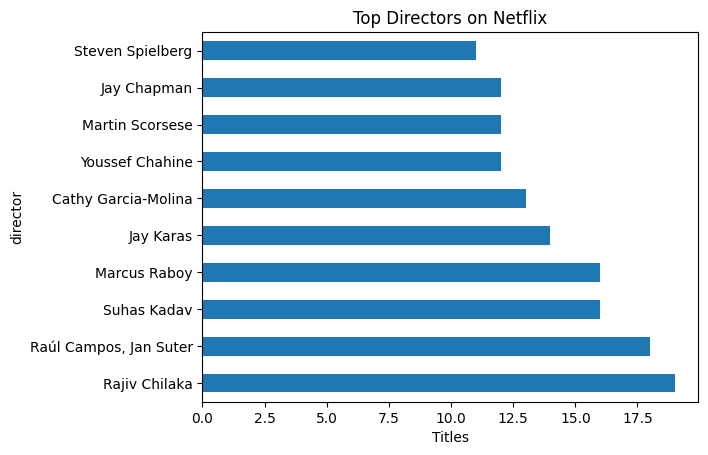

In [59]:
director.plot(kind='barh')

plt.title("Top Directors on Netflix")

plt.xlabel("Titles")

plt.show()

**Key Insights**
1. Movies make up a significantly larger portion of Netflix's content than TV Shows.
   This suggests Netflix has historically focused more on movies.
   
2. Drama-related genres appear most frequently.
   International Movies and TV Shows also have a strong presence, reflecting Netflix's global content strategy.

3. The U.S. has the highest number of titles on Netflix.
   Other major contributors include India, the United Kingdom, Canada, France, and Japan.

4. Ratings such as TV-MA and TV-14 are the most common.
   This indicates that a large portion of Netflix's catalog is aimed at teens and adults.

5. The number of titles added to Netflix increased rapidly between 2016 and 2019.
   This period represents a major expansion of the platform's content library.

6. The majority of movies fall within a typical feature-length duration.
   Extremely short or very long movies are relatively uncommon.

7. Some directors have multiple works on Netflix, while most appear only once.
   This shows a diverse set of content creators with a few prolific contributors.